In [33]:
import sys
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from visioniceio.experiment import Experiment

plt.style.use('../configs/plot_style.mplstyle')

In [2]:
dir_ = '/Users/friedrichschwarz/test_data/natal/c5607a07oldformat'

# Loading the Data

In [18]:
e_ = Experiment()
e_.load_from_dir(path=dir_, name='c5607a07', save_as='zarr')
e_.data

/Users/friedrichschwarz/mambaforge/envs/da_analysis/lib/python3.12/site-packages/zarr/creation.py:190: UserWarning: ignoring keyword argument 'compressors'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


<xarray.Dataset> Size: 3GB
Dimensions:       (electrodes: 32, trials: 240, spikes_idx: 4877,
                   snippet_time: 38, lfp_time: 2500)
Coordinates:
  * electrodes    (electrodes) int64 256B 0 1 2 3 4 5 6 ... 25 26 27 28 29 30 31
  * trials        (trials) int64 2kB 0 1 2 3 4 5 6 ... 234 235 236 237 238 239
  * spikes_idx    (spikes_idx) float64 39kB 0.0 3.125e-05 ... 2.438e+03
  * snippet_time  (snippet_time) float64 304B 0.0 3.125e-05 ... 0.001156
  * lfp_time      (lfp_time) float64 20kB 0.0 0.001 0.002 ... 2.497 2.498 2.499
Data variables:
    waveforms     (electrodes, trials, spikes_idx, snippet_time) float16 3GB ...
    n_spikes      (trials, electrodes) int32 31kB 61 171 5 9 19 ... 11 5 2 266
    spike_times   (electrodes, trials, spikes_idx) float32 150MB 0.08522 ... nan
    stim_label    (trials) int32 960B 9 10 4 9 10 3 4 2 6 ... 4 2 6 2 3 9 3 3 1
    lfp           (electrodes, trials, lfp_time) int16 38MB -339 40 ... 558 556
Attributes: (12/21)
    RecordName:                      c5607a07
    ProjectName:                     call
    DataPath:                        C:\SpassData\call\c56\c5607a07
    NofTrials:                       240
    MaxTrialLength:                  2500
    SpikeSamplingFrequency:          32000
    ...                              ...
    EnableTrialLabeling?:            True
    SpikeChannels:                   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, ...
    SpikeWaveformChannels:           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, ...
    AnalogChannels:                  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, ...
    UpperLimit:                      [250, 0]
    LowerLimit:                      [-250, 0]

---

# Some Plotting

## Waveform of a single channel over all trials

(38, 1170480)
(1170480, 38)
(14952, 38)


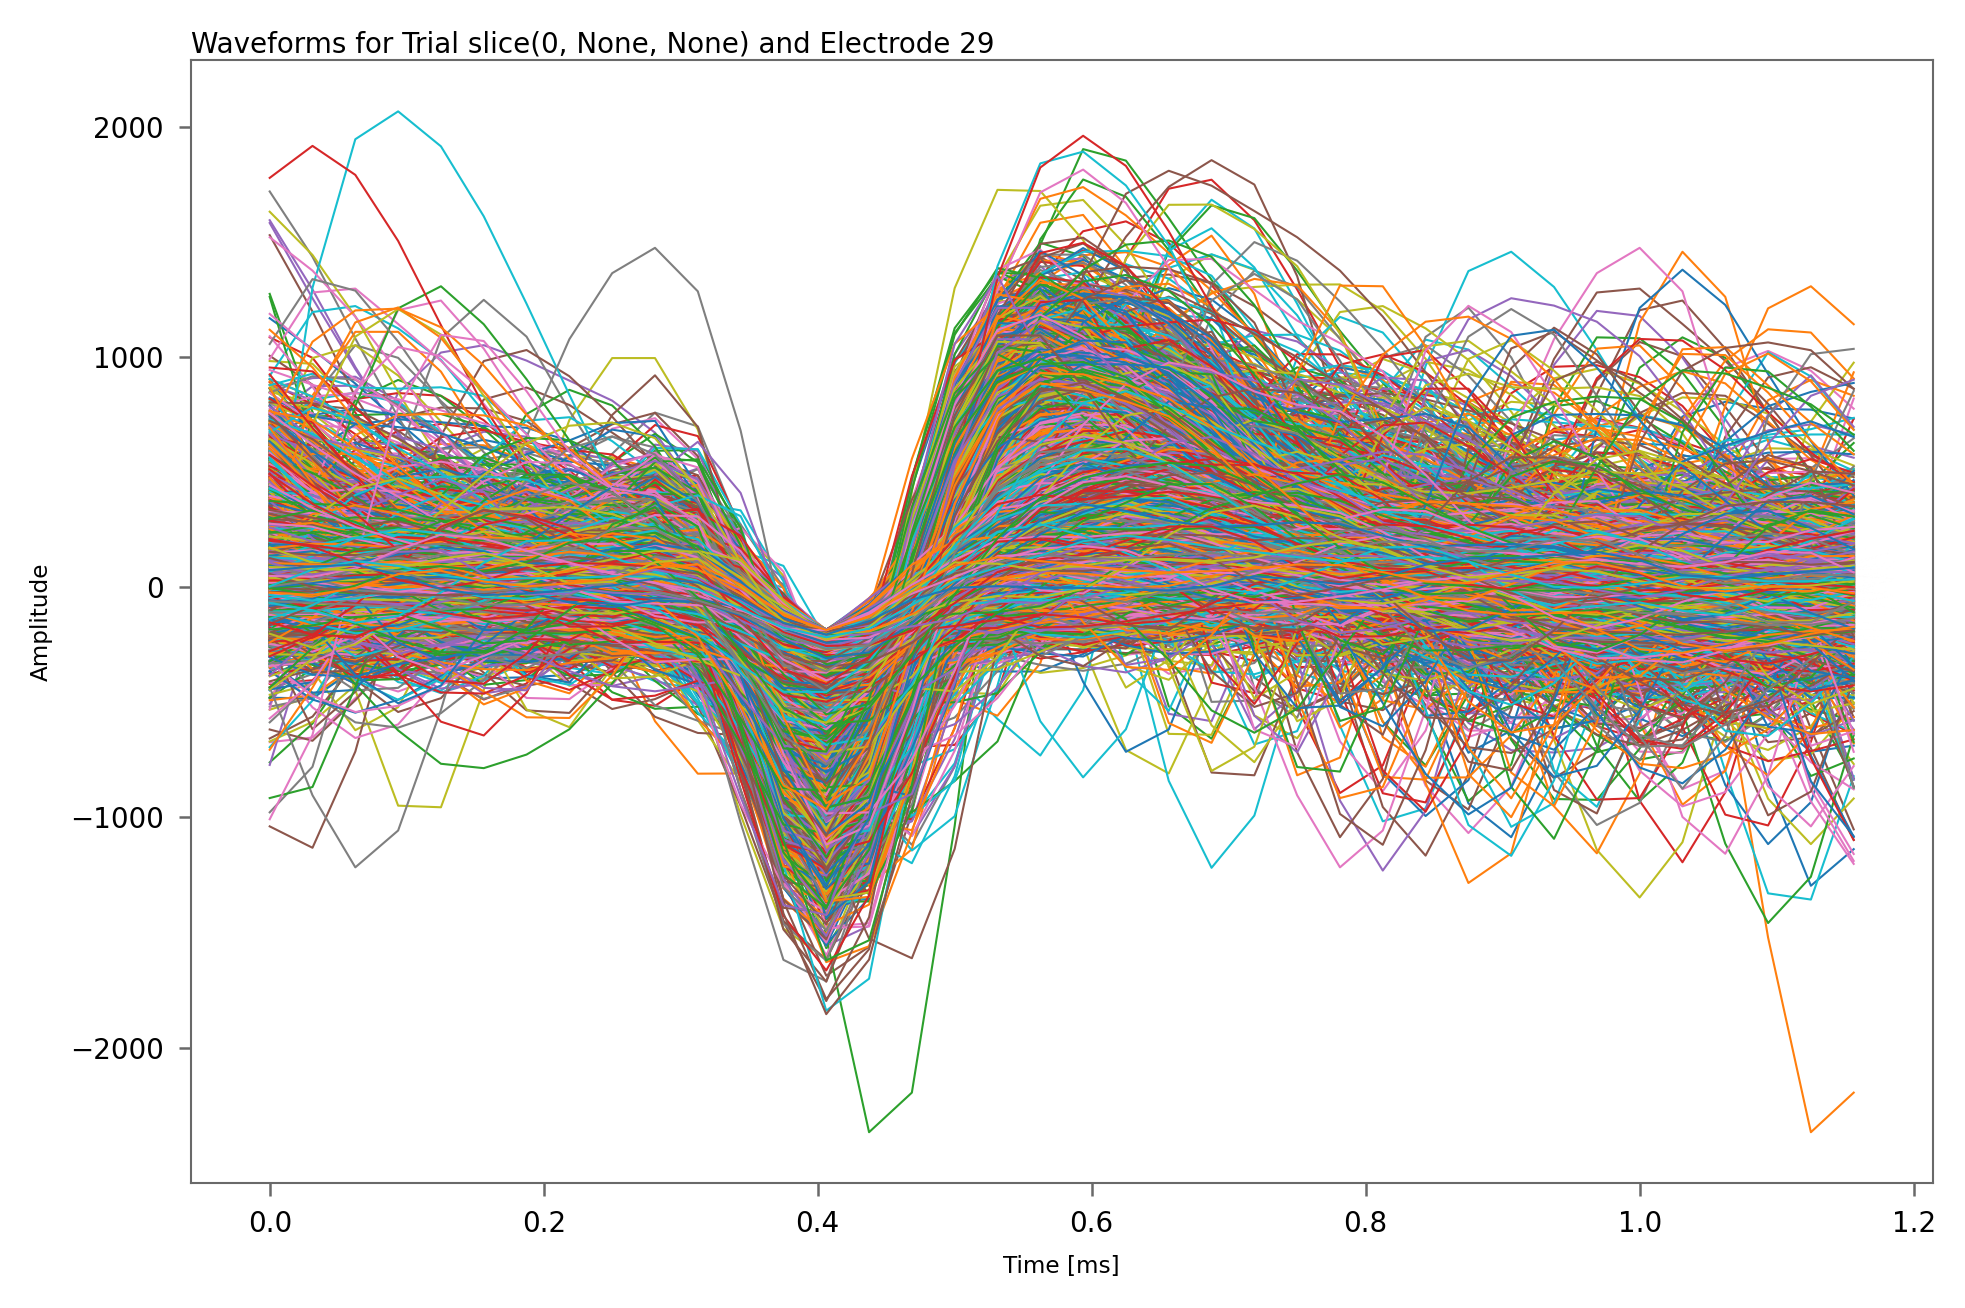

In [4]:
trial_ = slice(0, None) # 54 - 1
electrode_ = 29 - 1
waveforms = e_.data['waveforms'].sel(
    trials = trial_,
    electrodes = electrode_,
)
waveforms_stacked = waveforms.stack(channel=("trials", "spikes_idx"))
print(waveforms_stacked.shape)
waveforms_stacked = waveforms_stacked.loc[:, (waveforms_stacked != 0).any(dim="snippet_time")].T  # transpose n_i x time
print(waveforms_stacked.shape)
waveforms_stacked = waveforms_stacked.dropna(dim="channel", how="any")
print(waveforms_stacked.shape)
plt.plot(waveforms_stacked['snippet_time']*1_000, -waveforms_stacked.T)
# plt.plot(waveforms_stacked.T)
plt.title(f"Waveforms for Trial {trial_} and Electrode {electrode_+1}")

plt.xlabel("Time [ms]")
plt.ylabel("Amplitude")
plt.show()

---

## LFP of a single trial in one channel

(2500,)


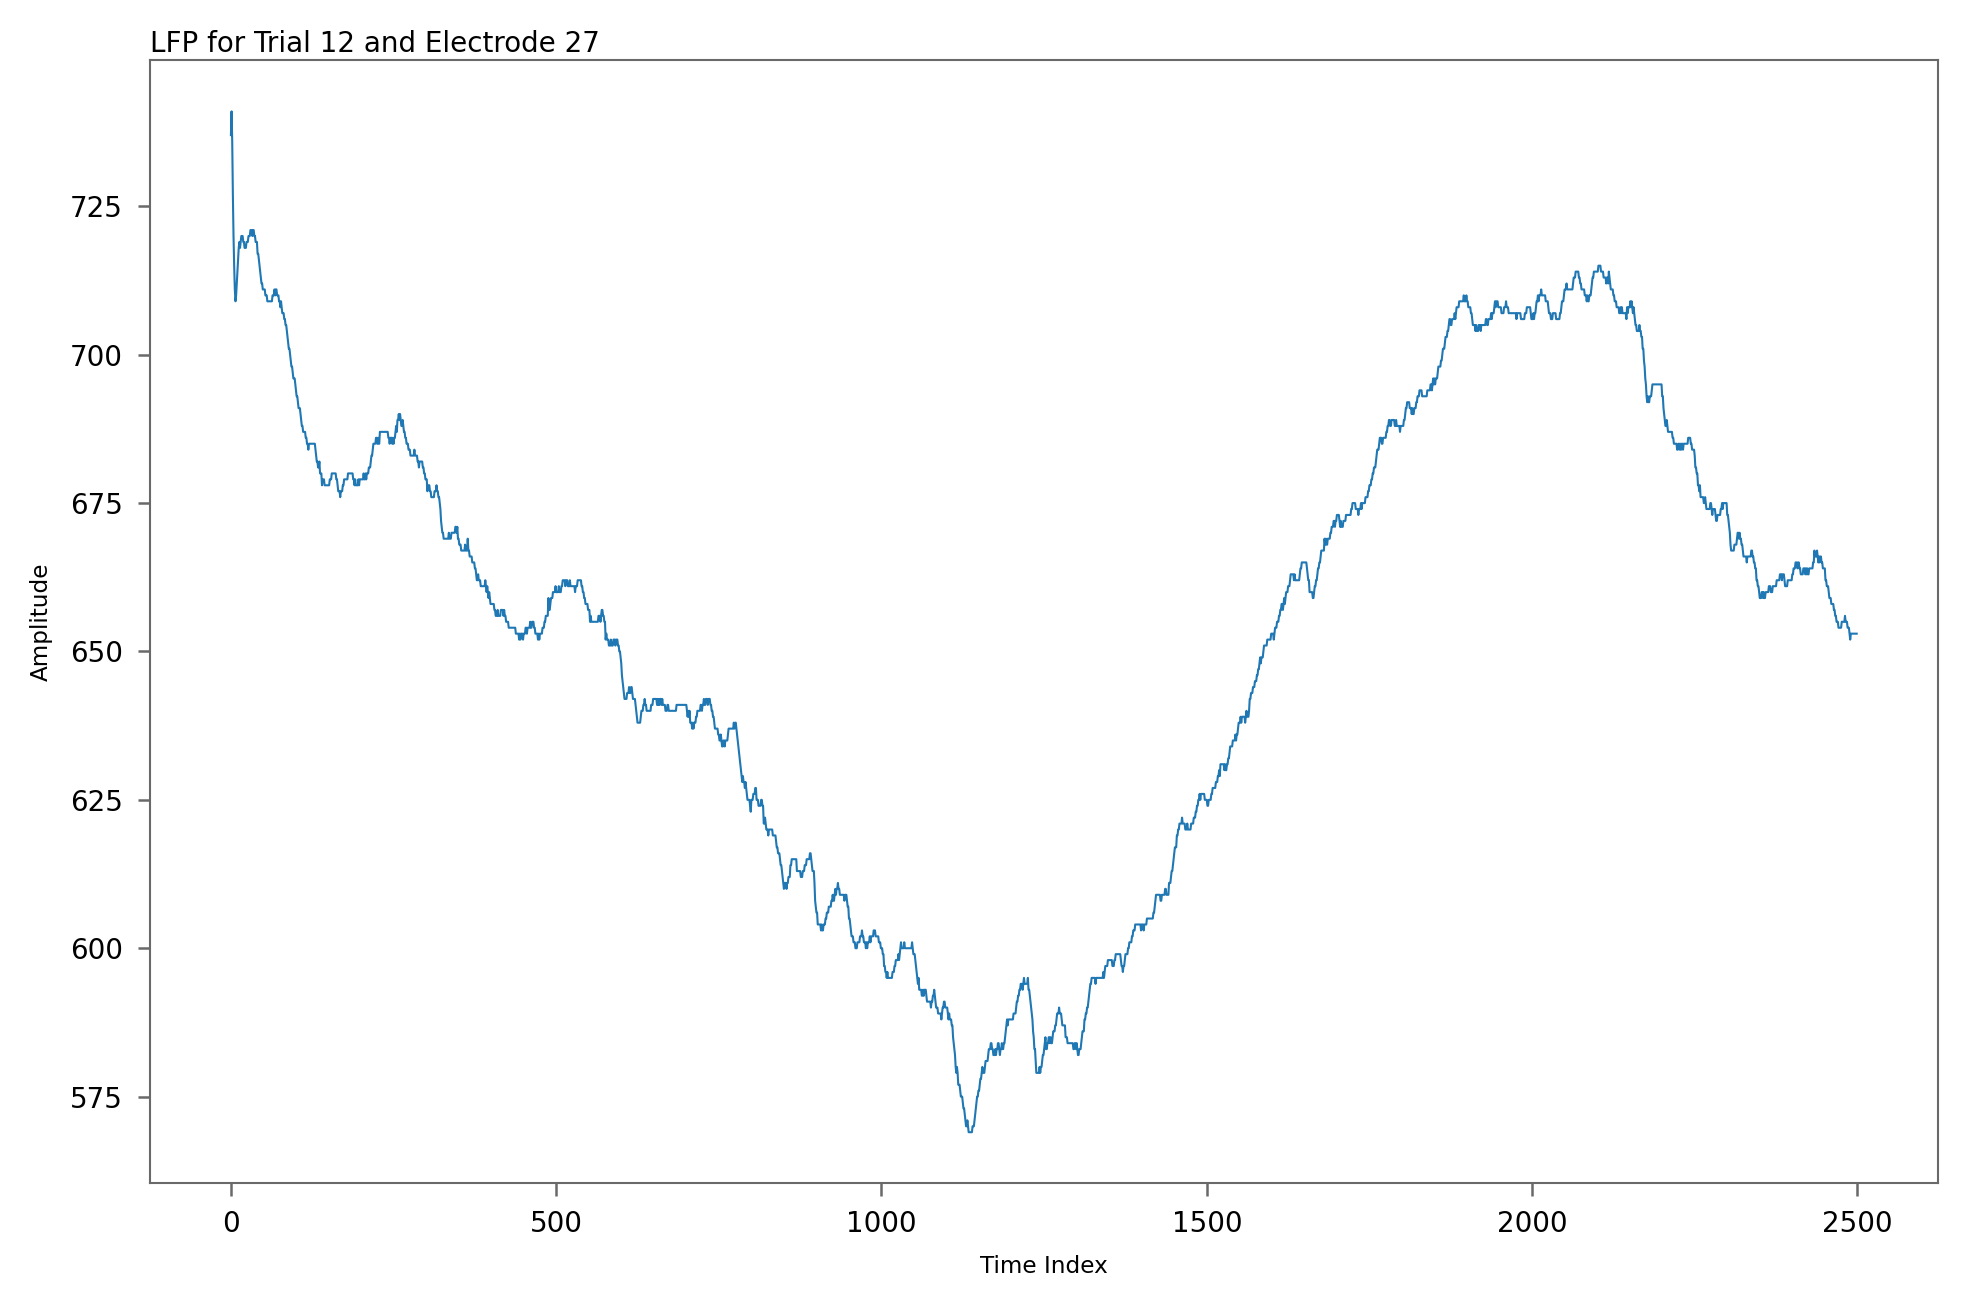

In [12]:
trial_ = 12 - 1
electrode_ = 27 - 1
waveforms = e_.data['lfp'].sel(
    trials = trial_,
    electrodes = electrode_,
)
print(waveforms.shape)
plt.plot(waveforms.T)
plt.title(f"LFP for Trial {trial_+1} and Electrode {electrode_+1}")
plt.xlabel("Time Index")
plt.ylabel("Amplitude")
plt.show()

---

## Spike raster plot of all channels for a single trial

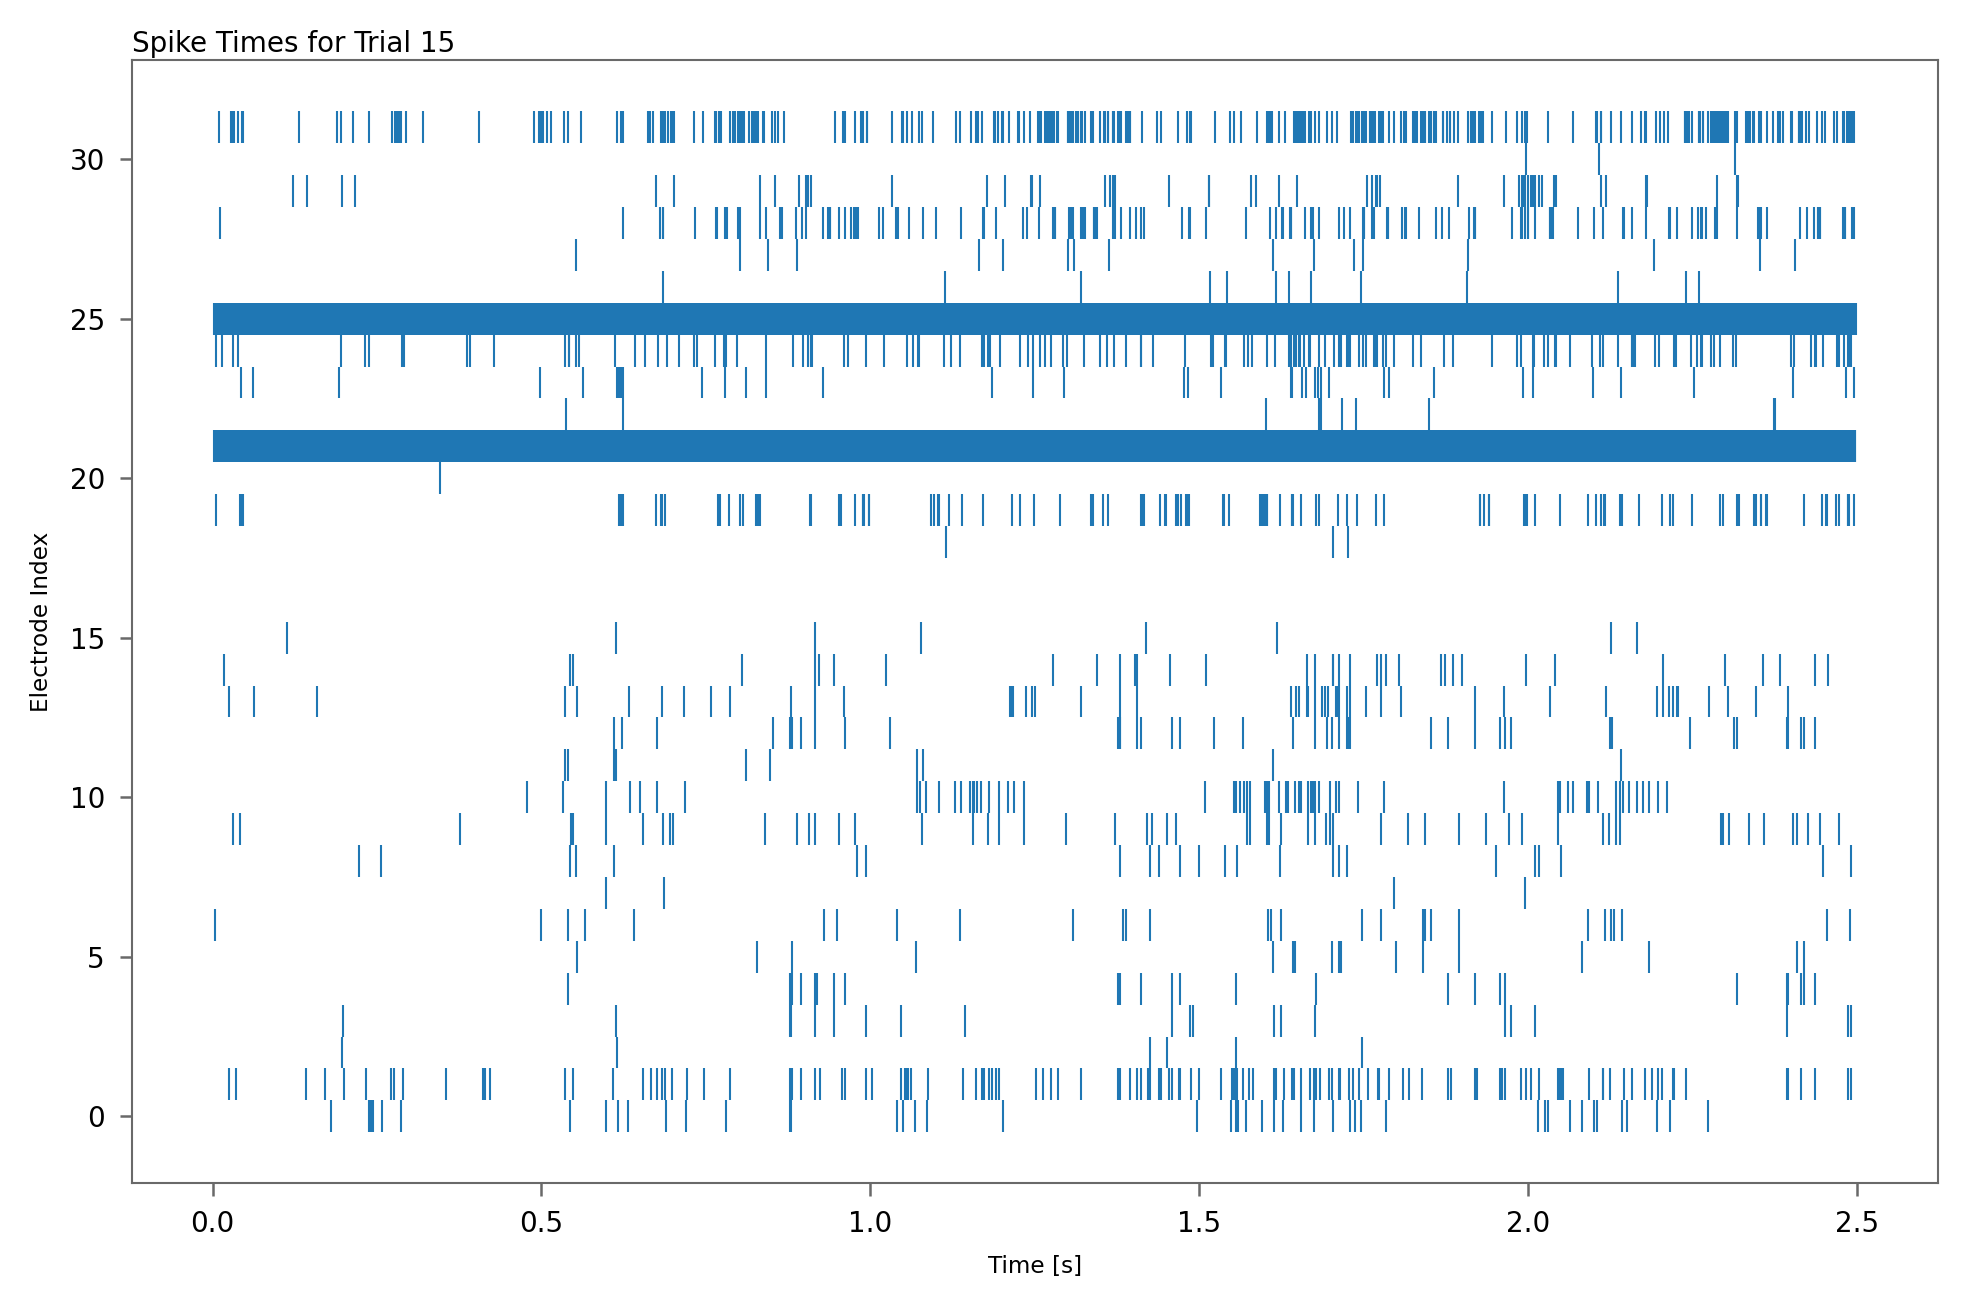

In [22]:
trial_ = 15 - 1
st_ = e_.data['spike_times'].sel(trials=trial_, electrodes=slice(0, None))
for ele_ in range(len(st_)):
    spike_times = st_.isel(electrodes=ele_).values[st_.isel(electrodes=ele_).values != 0]
    plt.vlines(spike_times, ele_ - 0.5, ele_ + 0.5)

plt.title(f"Spike Times for Trial {trial_+1}")
plt.xlabel("Time [s]")
plt.ylabel("Electrode Index")
plt.show()

---

## Correlation between channels over all LFP trials

In [23]:
ana_merged = e_.data['lfp'].stack(trial_combined=("trials", "lfp_time"))
ana_reshaped = ana_merged.transpose("electrodes", "trial_combined")
correlation_matrix = ana_reshaped.to_pandas().T.corr()
correlation_matrix

electrodes,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
electrodes,,,,,,,,,,,,,,,,,,,,,
0,1.000000,0.999516,0.998967,0.998415,0.997879,0.997333,0.996705,0.996033,0.989061,0.988651,...,0.993491,0.994751,0.996593,0.996088,0.995387,0.994398,0.994430,0.994488,0.994681,0.994944
1,0.999516,1.000000,0.999772,0.999413,0.998964,0.998484,0.997933,0.997354,0.990765,0.990040,...,0.991996,0.993680,0.996883,0.996534,0.996079,0.995283,0.995003,0.994759,0.994725,0.994905
2,0.998967,0.999772,1.000000,0.999843,0.999531,0.999129,0.998630,0.998081,0.991445,0.990851,...,0.990510,0.992342,0.996688,0.996461,0.996159,0.995586,0.995384,0.995072,0.994839,0.994825
3,0.998415,0.999413,0.999843,1.000000,0.999855,0.999588,0.999183,0.998698,0.992223,0.991656,...,0.989385,0.991285,0.996519,0.996374,0.996175,0.995743,0.995568,0.995280,0.995004,0.994898
4,0.997879,0.998964,0.999531,0.999855,1.000000,0.999878,0.999618,0.999232,0.992891,0.992403,...,0.988087,0.990024,0.996324,0.996227,0.996089,0.995760,0.995619,0.995397,0.995153,0.995020
5,0.997333,0.998484,0.999129,0.999588,0.999878,1.000000,0.999872,0.999618,0.993411,0.993054,...,0.986921,0.988871,0.996147,0.996084,0.996000,0.995770,0.995658,0.995474,0.995254,0.995117
6,0.996705,0.997933,0.998630,0.999183,0.999618,0.999872,1.000000,0.999878,0.993978,0.993732,...,0.985669,0.987629,0.995992,0.995961,0.995940,0.995794,0.995683,0.995510,0.995307,0.995186
7,0.996033,0.997354,0.998081,0.998698,0.999232,0.999618,0.999878,1.000000,0.994517,0.994342,...,0.984656,0.986589,0.995907,0.995909,0.995944,0.995871,0.995719,0.995535,0.995352,0.995250
8,0.989061,0.990765,0.991445,0.992223,0.992891,0.993411,0.993978,0.994517,1.000000,0.999291,...,0.975872,0.978474,0.996068,0.996645,0.997149,0.997402,0.996675,0.996121,0.995933,0.996094


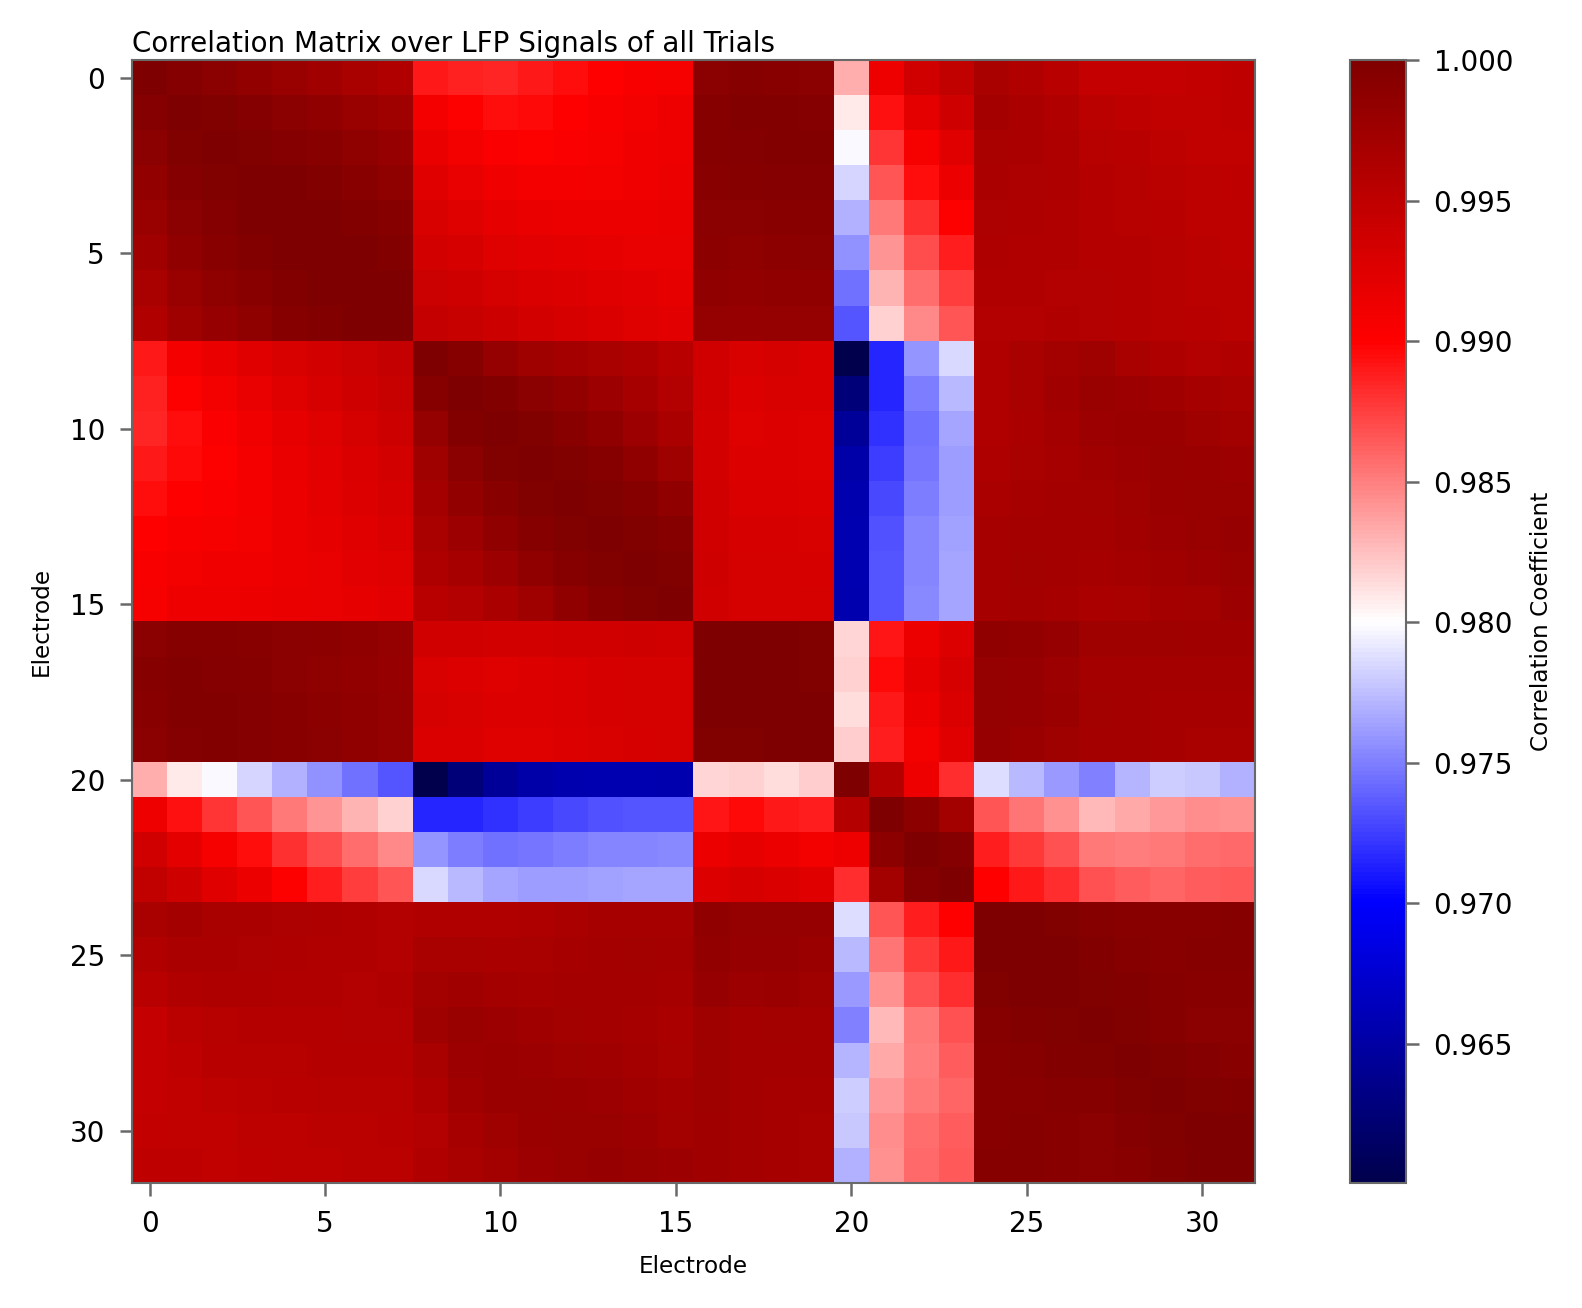

In [25]:
plt.imshow(correlation_matrix, cmap='seismic')
plt.colorbar(label='Correlation Coefficient')
plt.title('Correlation Matrix over LFP Signals of all Trials')
plt.xlabel('Electrode')
plt.ylabel('Electrode')
plt.show()

---
---

# Possible Windowed Correlation

In [28]:
def cov_window(x: np.ndarray) -> np.ndarray:
    # rows = variables (electrodes), columns = observations (timepoints)
    return np.cov(x)

In [30]:
window_size = 5000  # in data points -> 500ms at 10kHz sampling rate

rolling_window = ana_merged.rolling(trial_combined=window_size, center=True)

rolled = ana_merged.rolling(
    trial_combined=window_size, 
    min_periods=window_size
    ).construct('window_dim')

rolled

<xarray.DataArray 'lfp' (electrodes: 32, trial_combined: 600000,
                         window_dim: 5000)> Size: 384GB
array([[[  nan,   nan,   nan, ...,   nan,   nan, -339.],
        [  nan,   nan,   nan, ...,   nan, -339.,   40.],
        [  nan,   nan,   nan, ..., -339.,   40.,  298.],
        ...,
        [ 497.,  496.,  459., ...,  499.,  499.,  499.],
        [ 496.,  459.,  463., ...,  499.,  499.,  500.],
        [ 459.,  463.,  459., ...,  499.,  500.,  499.]],

       [[  nan,   nan,   nan, ...,   nan,   nan,  592.],
        [  nan,   nan,   nan, ...,   nan,  592.,  402.],
        [  nan,   nan,   nan, ...,  592.,  402.,  331.],
        ...,
        [ 507.,  507.,  492., ...,  509.,  509.,  509.],
        [ 507.,  492.,  491., ...,  509.,  509.,  510.],
        [ 492.,  491.,  485., ...,  509.,  510.,  510.]],

       [[  nan,   nan,   nan, ...,   nan,   nan,  696.],
        [  nan,   nan,   nan, ...,   nan,  696.,  664.],
        [  nan,   nan,   nan, ...,  696.,  664.,  594.],
        ...,
...
        [ 548.,  549.,  509., ...,  552.,  553.,  553.],
        [ 549.,  509.,  524., ...,  553.,  553.,  552.],
        [ 509.,  524.,  543., ...,  553.,  552.,  551.]],

       [[  nan,   nan,   nan, ...,   nan,   nan, 1089.],
        [  nan,   nan,   nan, ...,   nan, 1089., 1204.],
        [  nan,   nan,   nan, ..., 1089., 1204., 1330.],
        ...,
        [ 537.,  537.,  511., ...,  541.,  541.,  541.],
        [ 537.,  511.,  506., ...,  541.,  541.,  540.],
        [ 511.,  506.,  516., ...,  541.,  540.,  538.]],

       [[  nan,   nan,   nan, ...,   nan,   nan, 1016.],
        [  nan,   nan,   nan, ...,   nan, 1016., 1084.],
        [  nan,   nan,   nan, ..., 1016., 1084., 1182.],
        ...,
        [ 554.,  554.,  540., ...,  560.,  559.,  559.],
        [ 554.,  540.,  530., ...,  559.,  559.,  558.],
        [ 540.,  530.,  529., ...,  559.,  558.,  556.]]],
      shape=(32, 600000, 5000), dtype=float32)
Coordinates:
  * electrodes      (electrodes) int64 256B 0 1 2 3 4 5 6 ... 26 27 28 29 30 31
  * trial_combined  (trial_combined) object 5MB MultiIndex
  * trials          (trial_combined) int64 5MB 0 0 0 0 0 ... 239 239 239 239 239
  * lfp_time        (trial_combined) float64 5MB 0.0 0.001 0.002 ... 2.498 2.499
Dimensions without coordinates: window_dim

In [34]:
# compute rolling covariance (this step is memory-intensive and may take a while)
cov_da = xr.apply_ufunc(
    cov_window,
    rolled,
    input_core_dims=[['electrodes', 'window_dim']],
    output_core_dims=[['electrode_x', 'electrode_y']],
    vectorize=True,
    dask='parallelized',   # if you’re using dask-backed arrays
    output_dtypes=[float]
).rename({'electrode_x': 'electrodes', 'electrode_y': 'electrodes'})

cov_da

/Users/friedrichschwarz/mambaforge/envs/da_analysis/lib/python3.12/site-packages/xarray/namedarray/core.py:503: UserWarning: Duplicate dimension names present: dimensions {'electrodes'} appear more than once in dims=('trial_combined', 'electrodes', 'electrodes'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(value)


<xarray.DataArray 'lfp' (trial_combined: 600000, electrodes: 32)> Size: 5GB
array([[[          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        ...,
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan]],

       [[          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
...
         8271.35347069, 8275.57695139, 8267.56634527],
        [8313.15834287, 8314.7587041 , 8314.42082865, ...,
         8275.57695139, 8281.24634523, 8273.63062565],
        [8305.89527345, 8307.20473727, 8306.30461868, ...,
         8267.56634527, 8273.63062565, 8267.18040632]],

       [[8382.31363357, 8381.68681288, 8378.04825885, ...,
         8308.62365489, 8313.08187253, 8305.80032719],
        [8381.68681288, 8383.29654987, 8380.81990158, ...,
         8310.90143277, 8314.68231694, 8307.10995735],
        [8378.04825885, 8380.81990158, 8379.95758752, ...,
         8311.0854979 , 8314.36353351, 8306.22869134],
        ...,
        [8308.62365489, 8310.90143277, 8311.0854979 , ...,
         8271.2767992 , 8275.51917167, 8267.48944877],
        [8313.08187253, 8314.68231694, 8314.36353351, ...,
         8275.51917167, 8281.20773339, 8273.57273343],
        [8305.80032719, 8307.10995735, 8306.22869134, ...,
         8267.48944877, 8273.57273343, 8267.10328482]]],
      shape=(600000, 32, 32))
Coordinates:
  * trial_combined  (trial_combined) object 5MB MultiIndex
  * trials          (trial_combined) int64 5MB 0 0 0 0 0 ... 239 239 239 239 239
  * lfp_time        (trial_combined) float64 5MB 0.0 0.001 0.002 ... 2.498 2.499
Dimensions without coordinates: electrodes, electrodes

In [ ]:
from ipywidgets import interact, IntSlider

# assume cov_da is your DataArray of shape (trial_combined, electrodes, electrodes)
# and that window_size and n_samples are defined as before

def plot_covariance(window_idx):
    """
    Plots the covariance matrix for the given window index.
    """
    cov = np.log(cov_da.isel(trial_combined=window_idx).values)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cov, vmin=np.min(cov), vmax=np.max(cov), origin='lower')
    ax.set_title(f'Covariance Matrix (window ending at sample {window_idx})')
    ax.set_xlabel('Electrodes')
    ax.set_ylabel('Electrodes')
    plt.colorbar(im, ax=ax, label='Covariance')
    plt.tight_layout()
    plt.show()

# set slider from first full window (window_size-1) to last sample
start = window_size - 1
end = cov_da.sizes['trial_combined'] - 1

# create the interactive slider
slider = IntSlider(
    value=start,
    min=start,
    max=end,
    step=1,
    description='Sample idx:',
    continuous_update=False
)


In [ ]:
interact(plot_covariance, window_idx=slider)

interactive(children=(IntSlider(value=4999, continuous_update=False, description='Sample idx:', max=599999, mi…

<function __main__.plot_covariance(window_idx)>